In [1]:
import os
import sys
sys.path.insert(0, os.path.abspath('../../'))
from src.analysis.metrics import calculate_rmse, calculate_mape

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from statsmodels.tsa.api import VAR
from sklearn.metrics import mean_squared_error

In [2]:
# Restaurant data with the 25 most frequent ingredients
daily_consumption_df = pd.read_csv('../../data/restaurant_daily_consumption.csv', index_col=0, parse_dates=True)
display(daily_consumption_df)

output_size = daily_consumption_df.columns.size
target_columns = daily_consumption_df.columns

,Salt,Sugar,Clove,Paprika
Date,,,,
2019-01-01,153.557043,1573.765650,0.097426,2.455129
2019-01-02,101.122931,1036.382257,0.064158,1.616792
2019-01-03,119.849399,1228.304898,0.076040,1.916198
2019-01-04,97.377637,997.997729,0.061782,1.556911
2019-01-05,202.245861,2072.764515,0.128317,3.233584
...,...,...,...,...
2019-06-26,116.104106,1189.920370,0.073663,1.856317
2019-06-27,205.991155,2111.149043,0.130693,3.293465
2019-06-28,179.774099,1842.457347,0.114059,2.874297


##### **Apply Log Transformation**

In [3]:
# Apply log transformation to numerical features
df_log_transformed = daily_consumption_df.copy()
# Apply log1p (log(x + 1))
df_log_transformed = np.log1p(daily_consumption_df)
display(df_log_transformed)

# Check correlation
corr_matrix = df_log_transformed.corr()
display(corr_matrix)

,Salt,Sugar,Clove,Paprika
Date,,,,
2019-01-01,5.040563,7.361862,0.092967,1.239860
2019-01-02,4.626177,6.944456,0.062184,0.961949
2019-01-03,4.794545,7.114204,0.073287,1.070281
2019-01-04,4.588814,6.906753,0.059949,0.938800
2019-01-05,5.314416,7.637121,0.120727,1.443049
...,...,...,...,...
2019-06-26,4.763063,7.082482,0.071077,1.049533
2019-06-27,5.332676,7.655461,0.122831,1.457094
2019-06-28,5.197248,7.519398,0.108010,1.354364


,Salt,Sugar,Clove,Paprika
Salt,1.000000,0.999997,0.961587,0.995016
Sugar,0.999997,1.000000,0.960940,0.994756
Clove,0.961587,0.960940,1.000000,0.983050
Paprika,0.995016,0.994756,0.983050,1.000000


##### **Check if time series is stationary**

In [4]:
from statsmodels.tsa.stattools import adfuller

def check_stationarity(timeseries):
    isStationary = True

    # Perform the ADF test
    adf_result = adfuller(timeseries)
    adf_statistic = adf_result[0]
    p_value = adf_result[1]

    if p_value > 0.05:
        isStationary = False

    return adf_statistic, p_value, isStationary

# List to store the ADF test results
results = []

# Apply the check for each ingredient
for col in df_log_transformed.columns:
    adf_statistic, p_value, isStationary = check_stationarity(df_log_transformed[col])
    
    # Create a dictionary for each result
    result_dict = {
        'Ingredient': col,
        'ADF Statistic': adf_statistic,
        'p-value': p_value,
        'Stationarity Conclusion': "Series is stationary" if isStationary else "Series is not stationary"
    }
    
    # Append the dictionary to the results list
    results.append(result_dict)

# Convert the list of dictionaries to a DataFrame
adf_results = pd.DataFrame(results)
display(adf_results)

,Ingredient,ADF Statistic,p-value,Stationarity Conclusion
0,Salt,-2.226859,0.196642,Series is not stationary
1,Sugar,-2.221602,0.198499,Series is not stationary
2,Clove,-2.981528,0.036656,Series is stationary
3,Paprika,-2.471761,0.122497,Series is not stationary


##### **Making time series stationary**

In [5]:
from statsmodels.tsa.holtwinters import Holt

df_log_transformed = df_log_transformed.asfreq('D')

salt_series = df_log_transformed['Salt']
sugar_series = df_log_transformed['Sugar']
clove_series = df_log_transformed['Clove']
paprika_series = df_log_transformed['Paprika']

sugar_model = Holt(sugar_series)
sugar_results = sugar_model.fit(smoothing_level=0.15)
sugar_trend = sugar_results.fittedvalues
sugar_level = sugar_results.level
sugar_residual = sugar_series - sugar_trend

salt_model = Holt(salt_series)
salt_results = salt_model.fit(smoothing_level=0.15)
salt_trend = salt_results.fittedvalues
salt_level = salt_results.level
salt_residual = salt_series - salt_trend

clove_model = Holt(clove_series)
clove_results = clove_model.fit(smoothing_level=0.15)
clove_trend = clove_results.fittedvalues
clove_level = clove_results.level
clove_residual = clove_series - clove_trend

paprika_model = Holt(paprika_series)
paprika_results = paprika_model.fit(smoothing_level=0.15)
paprika_trend = paprika_results.fittedvalues
paprika_level = paprika_results.level
paprika_residual = paprika_series - paprika_trend


df_stationary_data = pd.concat({
    'Sugar': sugar_residual,
    'Salt': salt_residual,
    'Clove': clove_series,
    'Paprika': paprika_residual,
}, axis=1)

In [6]:
# Determine the split index for training and testing data - Holdout cross-validation
train_size = int(len(df_stationary_data) * 0.80) 

# Split the data into training and testing sets
df_train = df_stationary_data[:train_size]
df_test = df_stationary_data[train_size:]

In [7]:
# Fit the VAR model
model = VAR(df_train)

# Select the best lag feature
select_lag_feature = model.select_order(maxlags=10)
select_lag_feature.summary()

,AIC,BIC,FPE,HQIC
0,-30.21,-30.12,7.602e-14,-30.17
1,-34.09,-33.66*,1.567e-15,-33.91
2,-34.30,-33.52,1.267e-15,-33.99
3,-34.40,-33.28,1.146e-15,-33.95
4,-34.64,-33.17,9.127e-16,-34.04
5,-34.79,-32.98,7.824e-16,-34.06*
6,-34.86,-32.70,7.396e-16,-33.98
7,-34.99,-32.48,6.538e-16*,-33.97
8,-34.97,-32.12,6.763e-16,-33.81
9,-35.02*,-31.82,6.580e-16,-33.72


In [8]:
# Fitting the model with the chosen lag order
model_fitted = model.fit(9, ic='aic')
model_fitted.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Tue, 17, Sep, 2024
Time:                     20:56:19
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                   -31.8386
Nobs:                     135.000    HQIC:                  -33.7294
Log likelihood:           1745.87    FPE:                6.52220e-16
AIC:                     -35.0237    Det(Omega_mle):     2.47523e-16
--------------------------------------------------------------------
Results for equation Sugar
                coefficient       std. error           t-stat            prob
-----------------------------------------------------------------------------
const              1.133975         0.559455            2.027           0.043
L1.Sugar         412.087121       260.745297            1.580           0.114
L1.Salt         -428.490571       271.294209           -1.579           

Sugar RMSE: 946.1252921386966
Salt RMSE: 92.25133039057847
Clove RMSE: 0.05665446110837511
Paprika RMSE: 1.4325677549898683


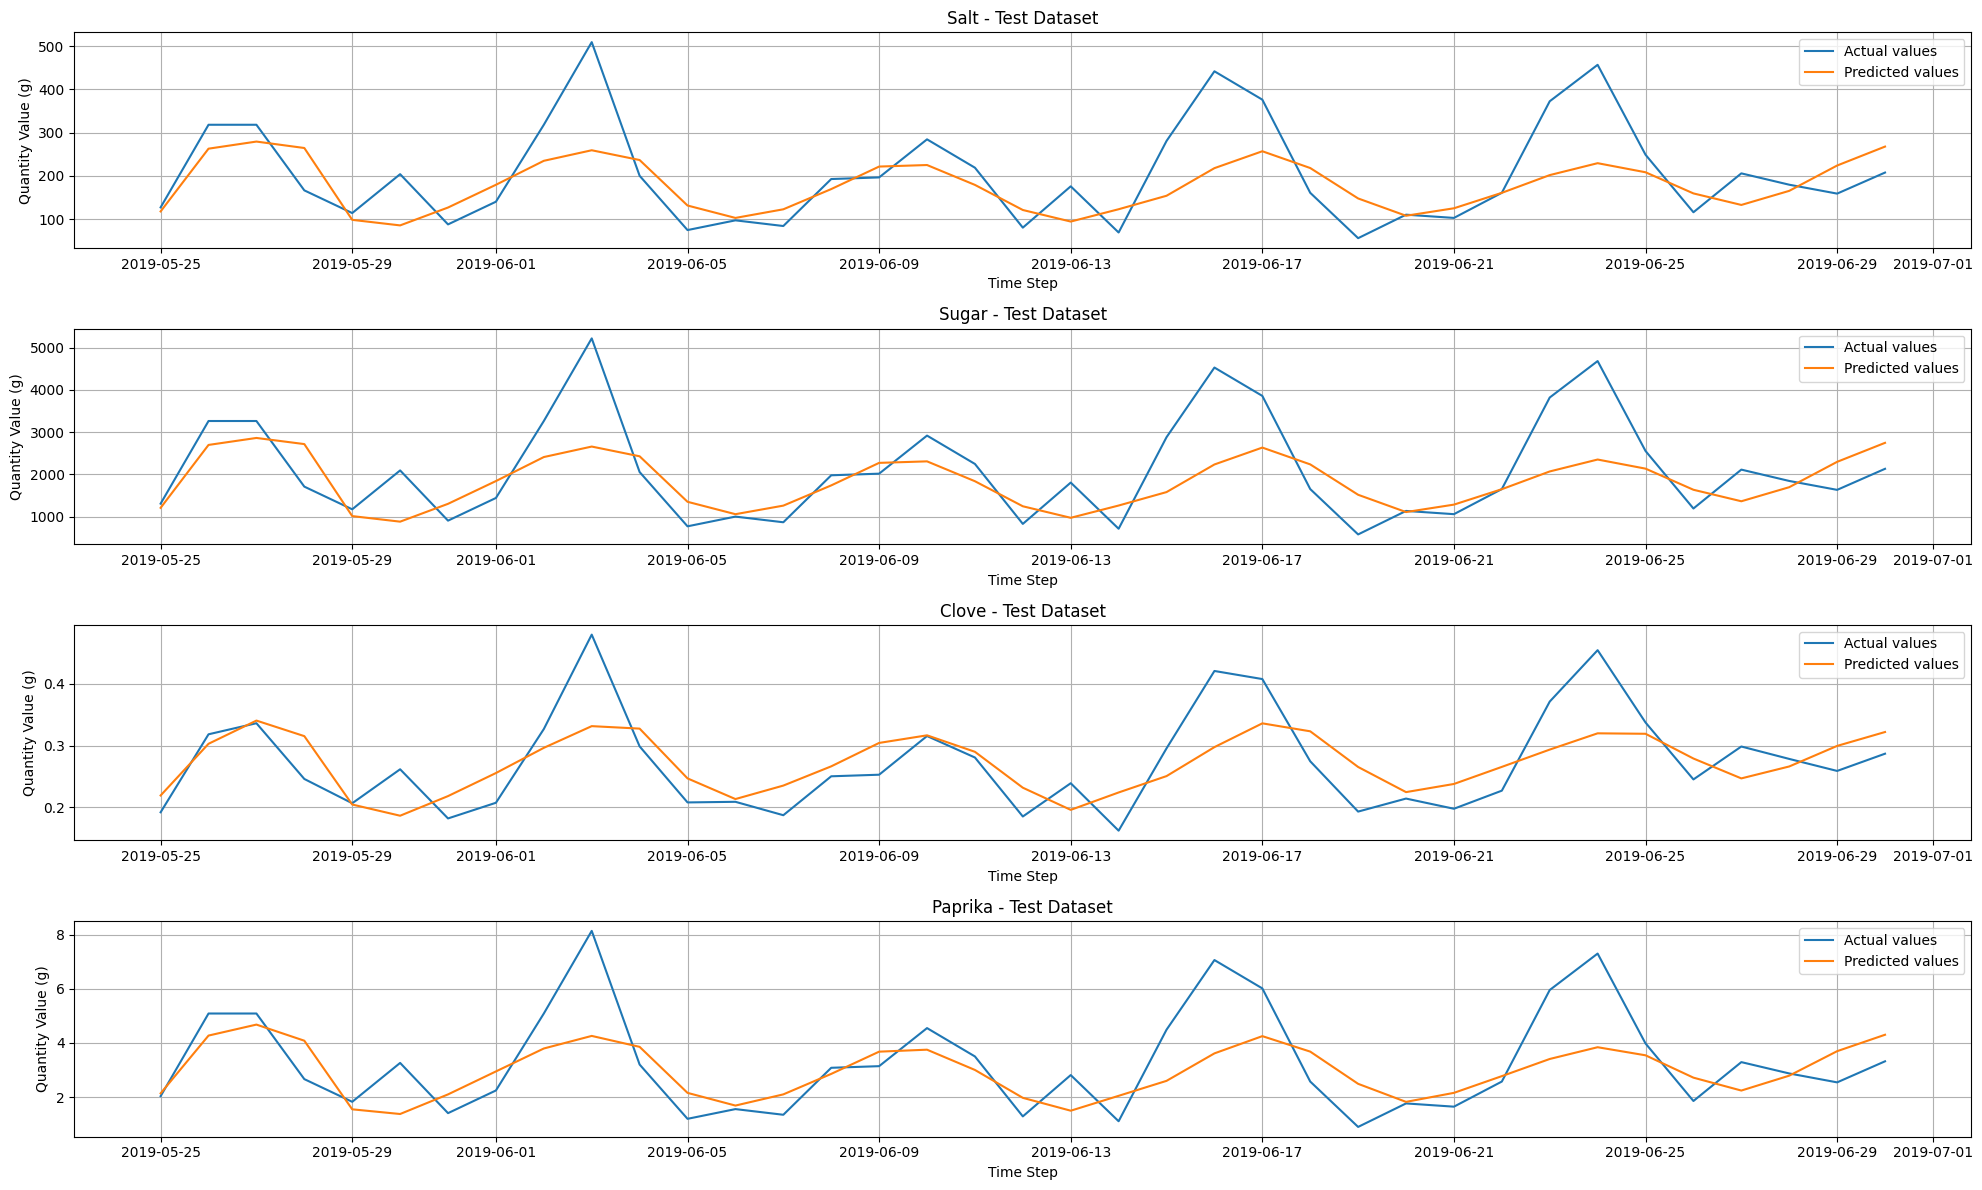

In [9]:
# Number of steps to forecast
forecast_steps = len(df_test) 

# Forecast using the fitted model
forecast = model_fitted.forecast(df_train.values[-model_fitted.k_ar:], steps=forecast_steps)
# Convert the forecast into a DataFrame
forecast_df = pd.DataFrame(forecast, columns=df_test.columns)
forecast_df.index = df_test.index[-forecast_steps:]

# Reverse the smoothing level from forecasted values
df_forecast_without_smooth = forecast_df.copy()
df_forecast_without_smooth['Salt'] += salt_trend[-forecast_steps:]
df_forecast_without_smooth['Sugar'] += sugar_trend[-forecast_steps:]
df_forecast_without_smooth['Clove'] += clove_trend[-forecast_steps:]
df_forecast_without_smooth['Paprika'] += paprika_trend[-forecast_steps:]


# Reverse the smoothing level from test values
df_test_without_smooth = df_test.copy()
df_test_without_smooth['Salt'] += salt_trend[-forecast_steps:]
df_test_without_smooth['Sugar'] += sugar_trend[-forecast_steps:]
df_test_without_smooth['Clove'] += clove_trend[-forecast_steps:]
df_test_without_smooth['Paprika'] += paprika_trend[-forecast_steps:]

# Reverse the log transformation
df_test_actuals = np.expm1(df_test_without_smooth)
df_test_forecast = np.expm1(df_forecast_without_smooth)

# # Initialize a dictionary to store RMSE values
rmse_dict = {}

# Calculate RMSE for each ingredient
for col in df_test.columns:
    # Extract actual and predicted values
    actual = df_test_actuals[col]
    predicted = df_test_forecast[col]
    
    # Calculate Root Mean Squared Error (RMSE)
    rmse = calculate_rmse(actual, predicted)
    
    # Store RMSE in the dictionary
    rmse_dict[col] = rmse

# Print RMSE for each ingredient
for ingredient, rmse in rmse_dict.items():
    print(f'{ingredient} RMSE: {rmse}')

# Plotting the predicted vs actual values for each output
fig, axes = plt.subplots(output_size, 1, figsize=(20, 3 * output_size))

# Plot actual vs. forecasted values
for idx, ingredient in enumerate(target_columns):
    # ingr_rmse = calculate_rmse(df_test_actuals[column], df_test_forecast[column])
    # print('RMSE: ', ingr_rmse)
    # ingr_mape = calculate_mape(df_test_actuals[column], df_test_forecast[column])
    # print('MAPE: ', ingr_mape)

    # plt.figure(figsize=(25, 4))
    # plt.plot(df_test_actuals.index, df_test_actuals[column], label='Actuals')
    # plt.plot(df_test_forecast.index, df_test_forecast[column], label='Predictions', linestyle='--')
    # plt.title(f'Actuals vs Predictions for {column}')
    # plt.xlabel('Time')
    # plt.ylabel(column)
    # plt.legend()
    # plt.grid(True)
    # plt.show()
    # Plot the results
    ax = axes[idx]
    ax.plot(df_test_actuals.index, df_test_actuals[ingredient], label='Actual values')
    ax.plot(df_test_actuals.index, df_test_forecast[ingredient], label='Predicted values')
    ax.set_title(f'{ingredient} - Test Dataset')
    ax.set_xlabel('Time Step')
    ax.set_ylabel('Quantity Value (g)')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()